In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, mean_absolute_error, classification_report
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import os
import time
from datetime import timedelta
import sys
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [4]:
class CEFRDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx]) - 1

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [5]:
df = pd.read_csv('ru_cefr_short.csv')
df['label'] = df['textbook-assigned cefr level'].astype(int)
df

,fragment,textbook-assigned cefr level,label
0,"Весной, летом и осенью почти каждую субботу он...",1,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,1
2,На каждой двери красные плакаты и красные фона...,1,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,1
...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,6
7320,Mapillary использует программное обеспечение д...,6,6


In [6]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['fragment'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"Размер обучающей выборки без аугментаций: {len(train_texts)}")
print(f"Размер валидационной выборки без аугментаций: {len(val_texts)}")

Размер обучающей выборки без аугментаций: 5857
Размер валидационной выборки без аугментаций: 1465


In [7]:
def fit(c2):
    model_name = 'sberbank-ai/ruBert-large'
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=6,
        id2label={0: 'A1', 1: 'A2', 2: 'B1', 3: 'B2', 4: 'C1', 5: 'C2'},
        label2id={'A1': 0, 'A2': 1, 'B1': 2, 'B2': 3, 'C1': 4, 'C2': 5}
    )
    
    model = model.to(device)
    print(f"Модель инициализирована")

    
    train_labels_aug = train_labels.tolist() + [6]*120
    train_texts_aug = train_texts.tolist() + c2['augmented-text'].tolist()
    
    train_dataset = CEFRDataset(train_texts_aug, train_labels_aug, tokenizer)
    val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)
    
    print(f"Обучающая выборка с аугментациями: {len(train_texts_aug)}")
    print(f"Валидационная выборка без аугментации: {len(val_texts)}")

    training_args = TrainingArguments(
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        warmup_steps=100,
        weight_decay=0.01,
        logging_steps=100,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='eval_loss',
        greater_is_better=False,
        learning_rate=2e-5
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
    )

    train_start_time = time.time()
    trainer.train()
    train_time = time.time() - train_start_time
    print(f"Обучение завершено за {train_time:.2f} секунд ({timedelta(seconds=int(train_time))})")

    return model, val_dataset, train_time
    

In [8]:
def predict(model, val_dataset, device, train_time):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for i in range(len(val_dataset)):
            batch = val_dataset[i]
            
            inputs = {
                'input_ids': batch['input_ids'].unsqueeze(0).to(device),
                'attention_mask': batch['attention_mask'].unsqueeze(0).to(device)
            }
            
            outputs = model(**inputs)
            pred = torch.argmax(outputs.logits, dim=1).item()
            predictions.append(pred + 1)  
            true_labels.append(batch['labels'].item() + 1)  

    accuracy = accuracy_score(true_labels, predictions)
    f1_micro = f1_score(true_labels, predictions, average="micro")
    f1_macro = f1_score(true_labels, predictions, average="macro")
    f1_weighted = f1_score(true_labels, predictions, average="weighted")
    mae = mean_absolute_error(true_labels, predictions)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Micro: {f1_micro:.4f}")
    print(f"F1 Macro: {f1_macro:.4f}")
    print(f"F1 Weighted: {f1_weighted:.4f}")
    print(f"MAE: {mae:.4f}")
    print(classification_report(true_labels, predictions))

    print(f"\n\n{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}\n{train_time:.2f}")
    
    return true_labels, predictions

In [9]:
def visualize_cm(true_labels, predictions):
    cm = confusion_matrix(true_labels, predictions)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    
    ax.set_xticks(range(6))
    ax.set_yticks(range(6))
    ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
    ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
    
    for i in range(6):
        for j in range(6):
            ax.text(j, i, cm[i, j], ha='center', va='center')
    
    plt.xlabel('Предсказанные')
    plt.ylabel('Истинные')
    plt.title('Матрица ошибок')
    plt.colorbar(im)
    plt.show()
    

# 3. Изменение порядка предложений

In [9]:
c2 = pd.read_csv('c2_augmented_3_t_lite.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.047700,0.979085
2,0.548800,1.009231
3,0.171300,1.518398


Обучение завершено за 326.34 секунд (0:05:26)


In [10]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6130
F1 Micro: 0.6130
F1 Macro: 0.5501
F1 Weighted: 0.6056
MAE: 0.4662
              precision    recall  f1-score   support

           1       0.93      0.41      0.56       153
           2       0.52      0.75      0.61       227
           3       0.59      0.74      0.66       475
           4       0.65      0.49      0.56       343
           5       0.67      0.59      0.63       237
           6       0.83      0.17      0.28        30

    accuracy                           0.61      1465
   macro avg       0.70      0.52      0.55      1465
weighted avg       0.65      0.61      0.61      1465



0.6130
0.6130
0.5501
0.6056
0.4662
326.34


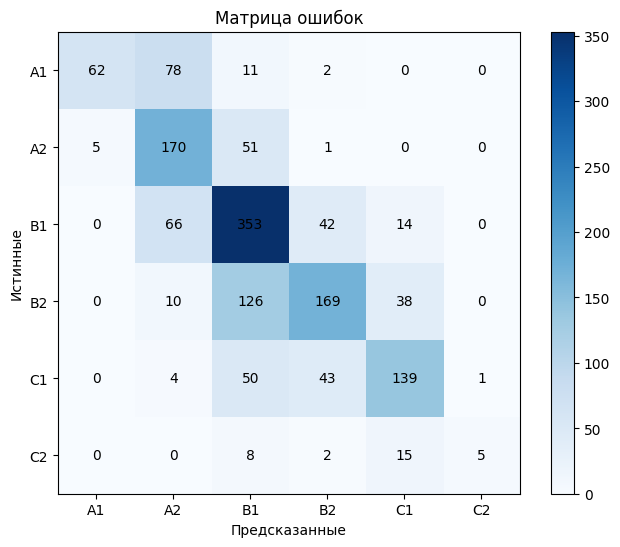

In [11]:
visualize_cm(true_labels, predictions)

# 4. Реорганизация фраз

In [12]:
c2 = pd.read_csv('c2_augmented_4_t_lite.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.026500,0.934813
2,0.518000,1.017395
3,0.144200,1.409244


Обучение завершено за 328.59 секунд (0:05:28)


In [13]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6321
F1 Micro: 0.6321
F1 Macro: 0.5735
F1 Weighted: 0.6286
MAE: 0.4416
              precision    recall  f1-score   support

           1       0.88      0.51      0.64       153
           2       0.55      0.72      0.63       227
           3       0.64      0.71      0.67       475
           4       0.63      0.57      0.60       343
           5       0.62      0.62      0.62       237
           6       0.83      0.17      0.28        30

    accuracy                           0.63      1465
   macro avg       0.69      0.55      0.57      1465
weighted avg       0.65      0.63      0.63      1465



0.6321
0.6321
0.5735
0.6286
0.4416
328.59


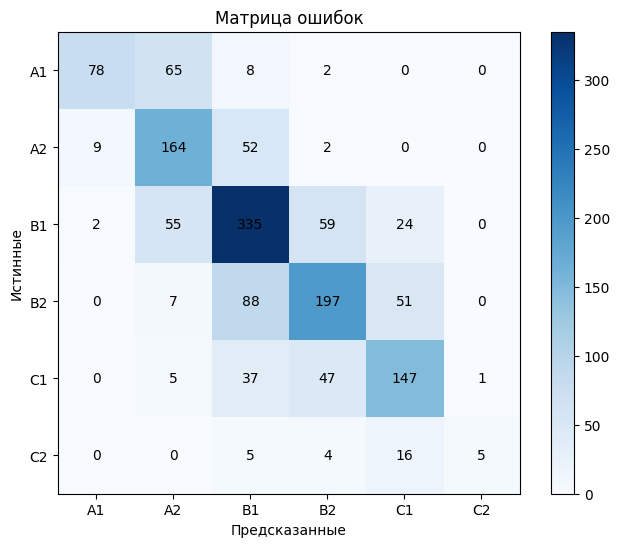

In [14]:
visualize_cm(true_labels, predictions)

# 5. Усложнение объяснений

In [15]:
c2 = pd.read_csv('c2_augmented_5_t_lite.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.025300,0.960115
2,0.536500,1.074730
3,0.146300,1.476905


Обучение завершено за 328.23 секунд (0:05:28)


In [16]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6123
F1 Micro: 0.6123
F1 Macro: 0.5388
F1 Weighted: 0.6072
MAE: 0.4594
              precision    recall  f1-score   support

           1       0.91      0.45      0.60       153
           2       0.52      0.74      0.61       227
           3       0.61      0.69      0.65       475
           4       0.61      0.55      0.58       343
           5       0.65      0.59      0.62       237
           6       0.60      0.10      0.17        30

    accuracy                           0.61      1465
   macro avg       0.65      0.52      0.54      1465
weighted avg       0.63      0.61      0.61      1465



0.6123
0.6123
0.5388
0.6072
0.4594
328.23


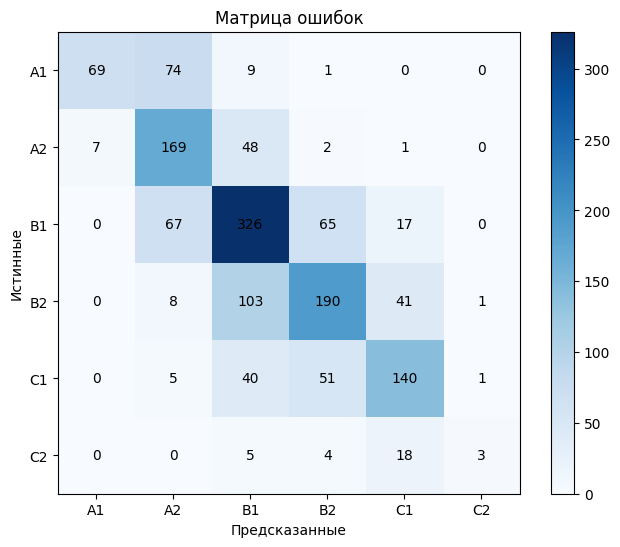

In [17]:
visualize_cm(true_labels, predictions)

# 8. Использованеи аналогий

In [18]:
c2 = pd.read_csv('c2_augmented_8_t_lite.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.032300,0.956890
2,0.523700,1.030204
3,0.128300,1.442840


Обучение завершено за 328.15 секунд (0:05:28)


In [19]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6123
F1 Micro: 0.6123
F1 Macro: 0.5272
F1 Weighted: 0.6057
MAE: 0.4608
              precision    recall  f1-score   support

           1       0.90      0.42      0.58       153
           2       0.52      0.75      0.61       227
           3       0.62      0.69      0.65       475
           4       0.60      0.57      0.59       343
           5       0.65      0.57      0.61       237
           6       1.00      0.07      0.12        30

    accuracy                           0.61      1465
   macro avg       0.72      0.51      0.53      1465
weighted avg       0.64      0.61      0.61      1465



0.6123
0.6123
0.5272
0.6057
0.4608
328.15


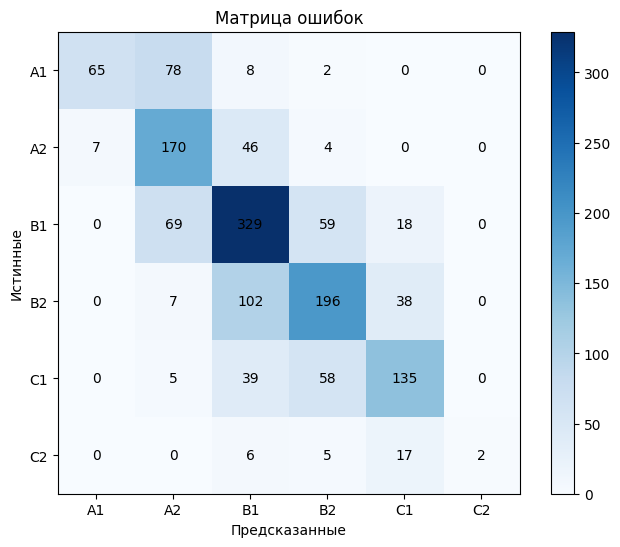

In [20]:
visualize_cm(true_labels, predictions)

# 9. Синтаксические трансформации

In [21]:
c2 = pd.read_csv('c2_augmented_9_t_lite.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.022600,0.940333
2,0.520600,0.999874
3,0.115000,1.433260


Обучение завершено за 327.75 секунд (0:05:27)


In [22]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6273
F1 Micro: 0.6273
F1 Macro: 0.5763
F1 Weighted: 0.6225
MAE: 0.4389
              precision    recall  f1-score   support

           1       0.91      0.41      0.57       153
           2       0.53      0.73      0.61       227
           3       0.63      0.73      0.68       475
           4       0.64      0.57      0.60       343
           5       0.65      0.59      0.62       237
           6       1.00      0.23      0.38        30

    accuracy                           0.63      1465
   macro avg       0.73      0.55      0.58      1465
weighted avg       0.66      0.63      0.62      1465



0.6273
0.6273
0.5763
0.6225
0.4389
327.75


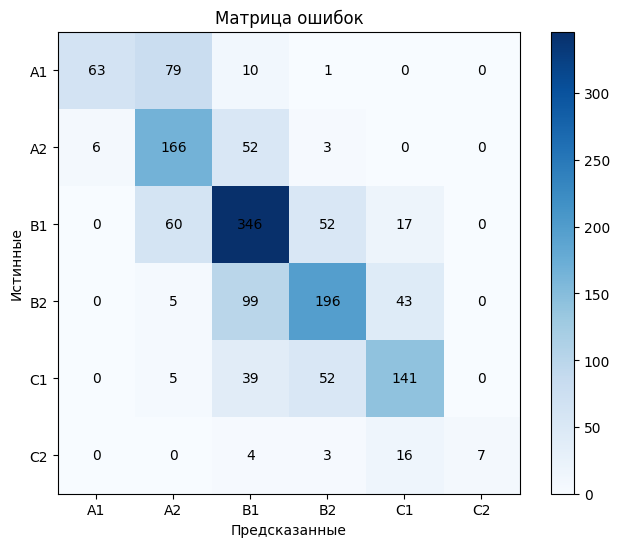

In [23]:
visualize_cm(true_labels, predictions)

# 11. Перефразирование

In [24]:
c2 = pd.read_csv('c2_augmented_11_t_lite.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.025800,0.940598
2,0.524900,1.018885
3,0.135900,1.408389


Обучение завершено за 328.05 секунд (0:05:28)


In [25]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6198
F1 Micro: 0.6198
F1 Macro: 0.5755
F1 Weighted: 0.6168
MAE: 0.4491
              precision    recall  f1-score   support

           1       0.89      0.46      0.61       153
           2       0.52      0.73      0.61       227
           3       0.62      0.70      0.66       475
           4       0.64      0.55      0.59       343
           5       0.64      0.60      0.62       237
           6       0.88      0.23      0.37        30

    accuracy                           0.62      1465
   macro avg       0.70      0.55      0.58      1465
weighted avg       0.64      0.62      0.62      1465



0.6198
0.6198
0.5755
0.6168
0.4491
328.05


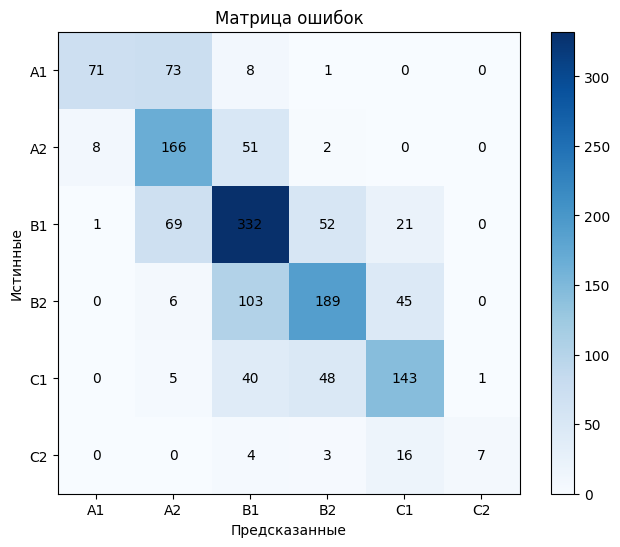

In [26]:
visualize_cm(true_labels, predictions)

# Генерация на примере

In [10]:
c2 = pd.read_csv('c2_generated_with_example_t_lite.csv')
c2.rename(columns={"generated-text": "augmented-text"}, inplace=True)
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.045800,0.984081
2,0.576300,0.986962
3,0.158500,1.323690


Обучение завершено за 326.36 секунд (0:05:26)


In [11]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6048
F1 Micro: 0.6048
F1 Macro: 0.5527
F1 Weighted: 0.5999
MAE: 0.4710
              precision    recall  f1-score   support

           1       0.90      0.50      0.64       153
           2       0.51      0.78      0.62       227
           3       0.59      0.70      0.64       475
           4       0.62      0.49      0.55       343
           5       0.66      0.53      0.59       237
           6       0.83      0.17      0.28        30

    accuracy                           0.60      1465
   macro avg       0.68      0.53      0.55      1465
weighted avg       0.63      0.60      0.60      1465



0.6048
0.6048
0.5527
0.5999
0.4710
326.36


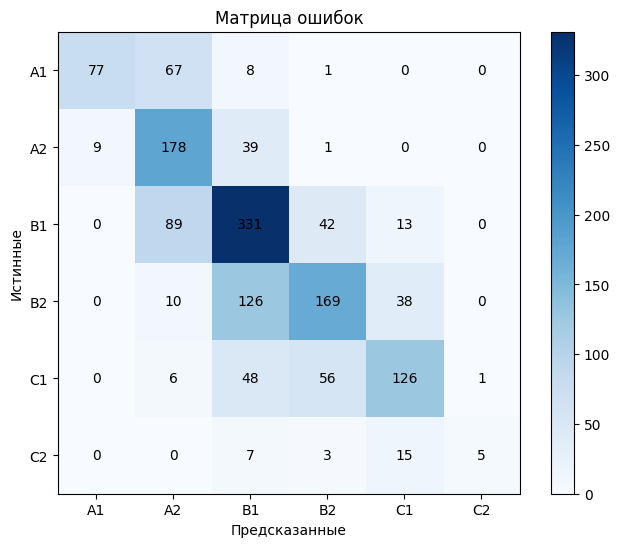

In [12]:
visualize_cm(true_labels, predictions)

# Генерация без примера

In [13]:
c2 = pd.read_csv('c2_generated_t_lite.csv')
c2.rename(columns={"generated-text": "augmented-text"}, inplace=True)
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.024900,0.961217
2,0.526500,1.006725
3,0.141800,1.431093


Обучение завершено за 327.94 секунд (0:05:27)


In [14]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6157
F1 Micro: 0.6157
F1 Macro: 0.5401
F1 Weighted: 0.6099
MAE: 0.4553
              precision    recall  f1-score   support

           1       0.92      0.43      0.59       153
           2       0.52      0.76      0.62       227
           3       0.62      0.69      0.66       475
           4       0.62      0.57      0.59       343
           5       0.64      0.58      0.61       237
           6       1.00      0.10      0.18        30

    accuracy                           0.62      1465
   macro avg       0.72      0.52      0.54      1465
weighted avg       0.65      0.62      0.61      1465



0.6157
0.6157
0.5401
0.6099
0.4553
327.94


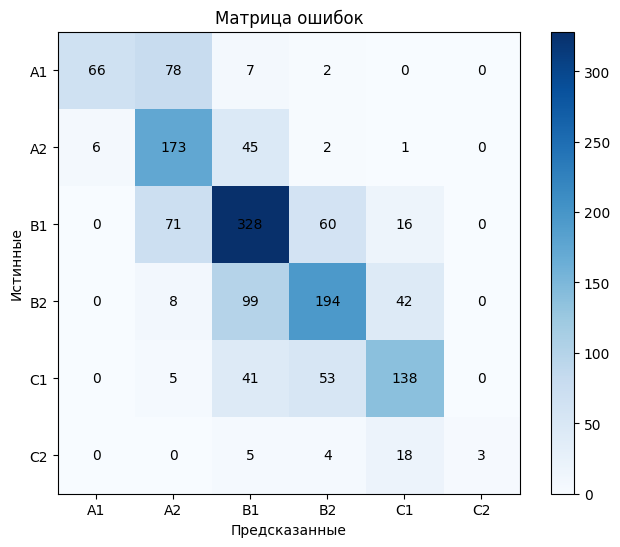

In [15]:
visualize_cm(true_labels, predictions)

# Аугментация из В2

In [16]:
c2 = pd.read_csv('c2_from_b2_augmented_t_lite.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.035400,0.955946
2,0.543200,1.075290
3,0.124600,1.490069


Обучение завершено за 327.88 секунд (0:05:27)


In [17]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6143
F1 Micro: 0.6143
F1 Macro: 0.5289
F1 Weighted: 0.6070
MAE: 0.4539
              precision    recall  f1-score   support

           1       0.89      0.44      0.59       153
           2       0.53      0.76      0.62       227
           3       0.62      0.71      0.66       475
           4       0.62      0.54      0.57       343
           5       0.64      0.58      0.61       237
           6       0.67      0.07      0.12        30

    accuracy                           0.61      1465
   macro avg       0.66      0.52      0.53      1465
weighted avg       0.64      0.61      0.61      1465



0.6143
0.6143
0.5289
0.6070
0.4539
327.88


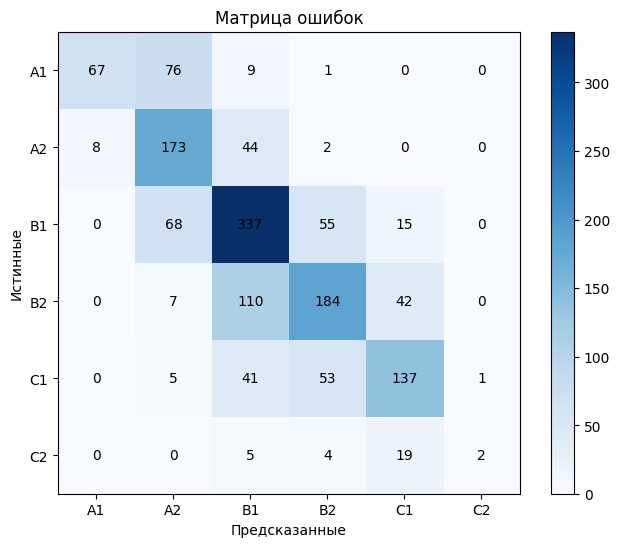

In [18]:
visualize_cm(true_labels, predictions)

# Аугментация из С1

In [19]:
c2 = pd.read_csv('c2_from_c1_augmented_t_lite.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.038300,0.983492
2,0.544900,1.070239
3,0.139200,1.459988


Обучение завершено за 328.01 секунд (0:05:28)


In [20]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6116
F1 Micro: 0.6116
F1 Macro: 0.5279
F1 Weighted: 0.6066
MAE: 0.4594
              precision    recall  f1-score   support

           1       0.91      0.48      0.63       153
           2       0.52      0.78      0.63       227
           3       0.61      0.70      0.65       475
           4       0.63      0.54      0.58       343
           5       0.64      0.53      0.58       237
           6       0.15      0.07      0.09        30

    accuracy                           0.61      1465
   macro avg       0.58      0.52      0.53      1465
weighted avg       0.63      0.61      0.61      1465



0.6116
0.6116
0.5279
0.6066
0.4594
328.01


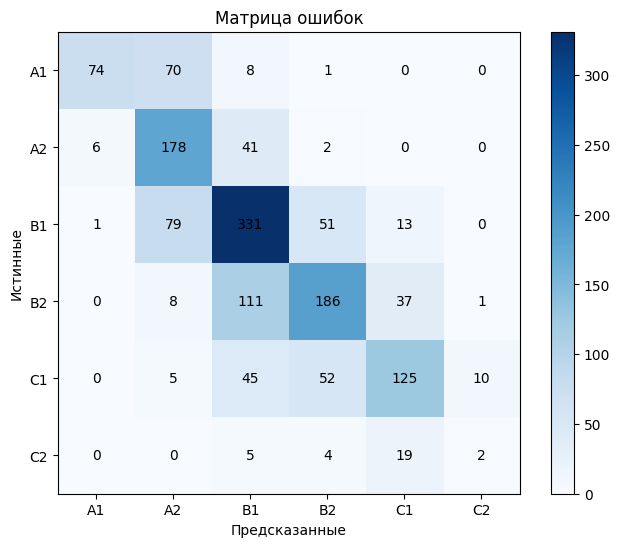

In [21]:
visualize_cm(true_labels, predictions)